# Public OpenNeuro ds003708 recipe

Run the public-data portability workflow and display a compact detector audit and signal figure directly on GitHub.

The stored tables and figures are derived exclusively from the public OpenNeuro ds003708 dataset. Raw downloads stay outside version control. Run the Python cells from top to bottom to reproduce the analysis.

In [1]:
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Allow this notebook to run from JupyterLab or from the repository root.
HERE = Path.cwd()
EXAMPLES = HERE if (HERE / "_synthetic.py").exists() else HERE / "notebooks" / "examples"
sys.path.insert(0, str(EXAMPLES.resolve()))
REPOSITORY = EXAMPLES.parents[1]
if (REPOSITORY / "ERPy").exists():
    sys.path.insert(0, str(REPOSITORY.resolve()))

import ERPy as ep
import ERPy.viz as viz
from IPython.display import Image, display as show_output
from _synthetic import (
    make_detection_table,
    make_edges,
    make_electrode_metadata,
    make_epochs,
    make_metric_table,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})

# The publication workflow stores PNGs so the figures render directly on GitHub.
get_ipython().run_line_magic("matplotlib", "inline")

def show_plotly_snapshot(figure):
    # Use figure.show() to interact locally; these PNGs also render on GitHub.
    import plotly.graph_objects as go
    preview = go.Figure(figure)
    preview.layout.sliders = ()
    preview.layout.updatemenus = ()
    preview.update_layout(
        legend={"orientation": "h", "y": -0.08, "x": 0.05},
        margin={"l": 30, "r": 100, "t": 65, "b": 70},
    )
    show_output(Image(preview.to_image(format="png", width=1000, height=650, scale=1)))

The Miller–Müller–Hermes basis-profile dataset is available as OpenNeuro
[`ds003708`](https://openneuro.org/datasets/ds003708/versions/1.0.4), snapshot
v1.0.4. The cells below download a bounded interval spanning 17 stimulation
events, keep at most 32 channels, and run ERPy's public validation pipeline.
The recipe pins explicit S3 object versions and verifies expected metadata
checksums and the previously recorded signal-window checksum before analysis.
The source contract is in `validation/public_ds003708_source_manifest.json`.
It records the snapshot commit and the scope of verification: the full 2.9 GB
recording is not downloaded or rehashed by this bounded recipe.

This is a real public recording. Notebooks 01–06 use synthetic fixtures;
notebook 00 uses an access-controlled cohort illustration. This public recipe
is a portability demonstration, with no
adjudicated response ground truth. Its calls are not sensitivity/specificity
estimates or clinical interpretations. The full local workspace is ignored by
Git; only the compact outputs below are committed. Install the `validation`
extra before running this notebook. An initial run requires network access.

In [2]:
import hashlib
import json
from validation.validate_public_spes import DATASETS, run_dataset

workspace = REPOSITORY / "validation" / "public_spes_work_notebook"
source_manifest = json.loads(
    (REPOSITORY / "validation" / "public_ds003708_source_manifest.json").read_text()
)
summaries = run_dataset(
    DATASETS["ds003708"], out_root=workspace,
    min_events=8, max_events=17, max_sites=1, max_channels=32,
    make_figures=False, prefer_cache=False, source_manifest=source_manifest,
)
summary = summaries[0]
site_root = Path(summary["workspace"])
raw_window = next((site_root / "raw").glob("*.csv"))
provenance = {
    "dataset": summary["dataset_id"],
    "source": summary["source_note"],
    "events_url": summary["source_events_url"],
    "signal_url": summary["source_eeg_url"],
    "downloaded_window_sha256": hashlib.sha256(raw_window.read_bytes()).hexdigest(),
    "source_sample_range": [summary["source_start_sample"], summary["source_stop_sample"]],
    "range_bytes_downloaded": summary["range_bytes_downloaded"],
    "source_window_cache_used": summary.get("source_window_cache_used", False),
    "source_identity_verified": summary["source_identity_verified"],
    "snapshot_git_commit": summary["source_snapshot_commit"],
    "downloaded_range_sha256": summary["source_range_sha256"],
    "ERPy_version": ep.__version__,
}
print(json.dumps(provenance, indent=2))

{
  "dataset": "ds003708",
  "source": "open preprocessed BrainVision signal derivative from the published dataset",
  "events_url": "https://s3.amazonaws.com/openneuro.org/ds003708/derivatives/preprocessed/sub-01/ses-ieeg01/ieeg/sub-01_ses-ieeg01_task-ccep_run-01_events.tsv?versionId=Vrluqey2gIp00yvaxuJKeaYDYcabHSJg",
  "signal_url": "https://s3.amazonaws.com/openneuro.org/ds003708/derivatives/preprocessed/sub-01/ses-ieeg01/ieeg/sub-01_ses-ieeg01_task-ccep_run-01_ieeg.eeg?versionId=ekxCFJH.NE2DhaUDkQ_Nc0iIxeHeLgF4",
  "downloaded_window_sha256": "44366721db57a472c5e737598d72641f0b754c2955bfaeef25fe51abceb195ad",
  "source_sample_range": [
    1043299,
    1390762
  ],
  "range_bytes_downloaded": 123696828,
  "source_window_cache_used": false,
  "source_identity_verified": true,
  "snapshot_git_commit": "eb80e3d2f13e066c387ef8d101a290d18a40eb27",
  "downloaded_range_sha256": "134ec1b0c9b80101596fc38343eb300e4ab0d104a35d8a4ab3b252856a4abb5b",
  "ERPy_version": "1.0.0"
}


In [3]:
summary_keys = [
    "stim_pair", "n_source_events_used", "sfreq", "n_epochs",
    "n_epochs_after_artifact_qc", "n_flagged_artifact_responses",
    "post_artifact_anchor_median_ms", "primary_epoch_passband_hz",
    "crowther_gamma_available",
]
show_output(pd.Series({key: summary[key] for key in summary_keys}, name="Run summary").to_frame())
public_detections = pd.read_csv(site_root / "detections.csv")
primary = public_detections.loc[public_detections.method.eq("crp_energy")].copy()
columns = [
    "channel", "p_crp", "p_energy", "p_joint", "q_joint",
    "primary_classification", "primary_significant",
]
print(int(primary.primary_significant.sum()), "primary response calls across", len(primary), "retained channels")
primary[columns].head(12)

,Run summary
stim_pair,LTG_1_2
n_source_events_used,17
sfreq,2048.0
n_epochs,17
n_epochs_after_artifact_qc,17
n_flagged_artifact_responses,40
post_artifact_anchor_median_ms,9.76562
primary_epoch_passband_hz,"[0.5, 80.0]"
crowther_gamma_available,False


11 primary response calls across 30 retained channels


,channel,p_crp,p_energy,p_joint,q_joint,primary_classification,primary_significant
90,LAS1,0.000200,0.006714,0.006714,0.022380,reproducible_energetic,True
91,LAS2,0.001400,0.174713,0.174713,0.248212,reproducible_low_energy,False
92,LAS3,0.000200,0.015289,0.015289,0.041698,reproducible_energetic,True
93,LAS4,0.000200,0.004199,0.004199,0.017996,reproducible_energetic,True
94,LMS1,0.028794,0.006199,0.028794,0.071986,reproducible_energetic,False
95,LMS2,0.004999,0.001400,0.004999,0.018746,reproducible_energetic,True
96,LMS3,0.000200,0.091382,0.091382,0.143371,reproducible_low_energy,False
97,LMS4,0.000200,0.003999,0.003999,0.017996,reproducible_energetic,True
98,LPS1,0.023595,0.045578,0.045578,0.085459,reproducible_energetic,False
99,LPS2,0.095581,0.012894,0.095581,0.143371,energetic_inconsistent,False


The retained `p_crp` field on a `crp_energy` row is the fixed-window
reproducibility value $p_R$. The final primary call requires both components,
family adjustment, and artifact eligibility. SIGNI/high gamma is explicitly
unavailable because this public pipeline uses 0.5–80 Hz epochs without a
separate 70–170 Hz input. The agreement figure below includes available
methods only; the unavailable SIGNI row is excluded.

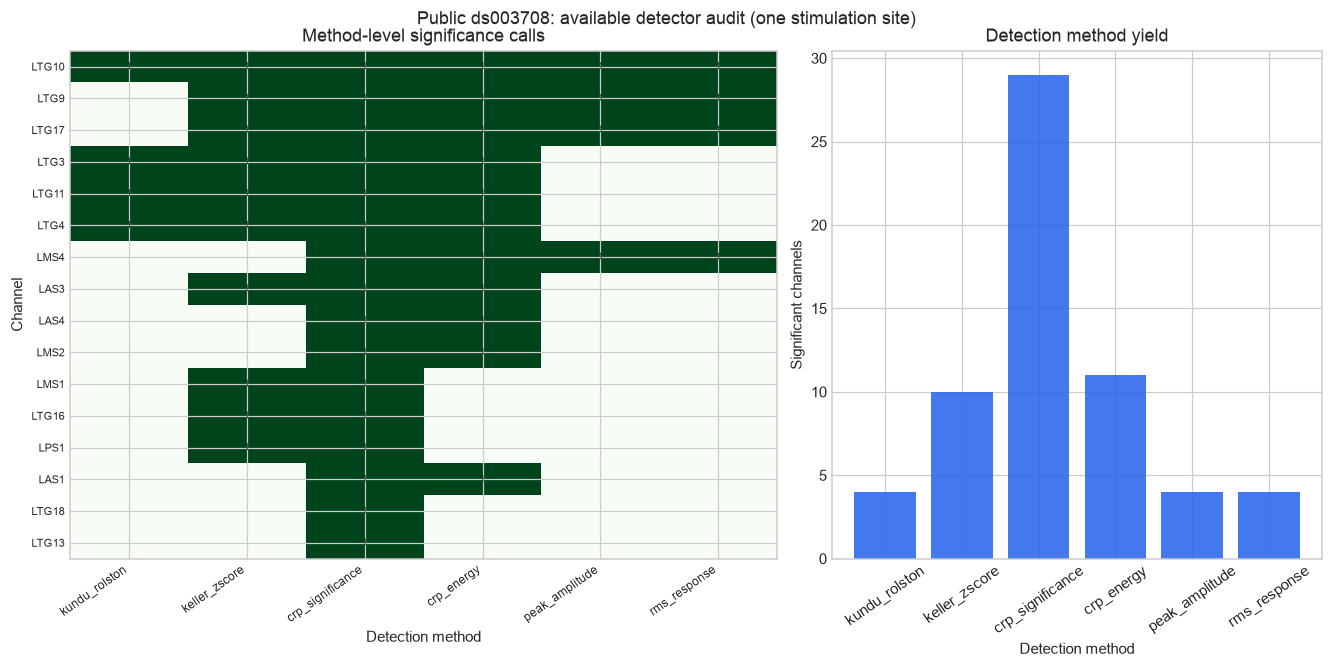

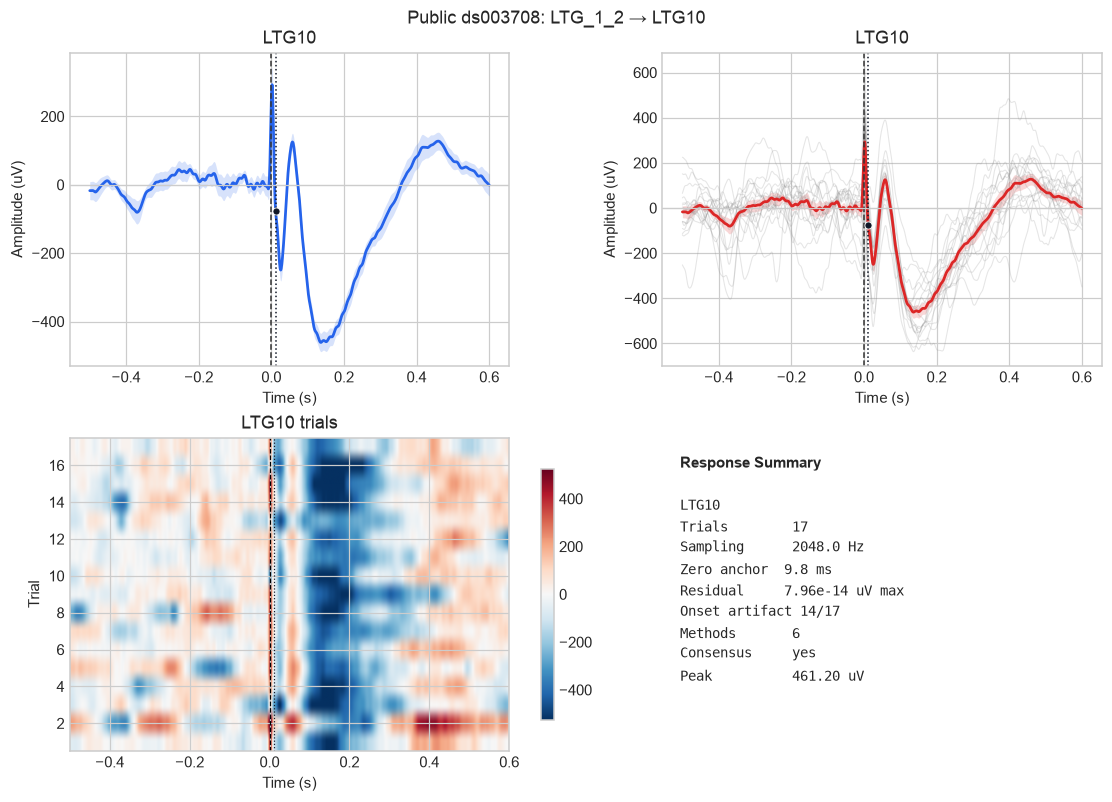

In [4]:
available_detections = public_detections.loc[public_detections.method.ne("crowther_gamma")]
fig = viz.plot_detection_summary(available_detections, top_n=16)
fig.suptitle("Public ds003708: available detector audit (one stimulation site)", y=1.02)
plt.show()

# Rebuild the same epoch stream for a waveform view from the downloaded data.
patient = ep.Patient("DS003708", config_path=str(site_root / "config.yaml"))
steps = [
    ("reject_bad_channels", {"bad_channels": "auto", "method": "drop", "detection_params": {"zscore_threshold": 8.0}}),
    ("artifact_blank", {"width_s": 0.004}),
    ("notch_filter", {"notch_freq": 60.0, "bw": 2.0, "harm": True}),
    ("bandpass_filter", {"lowcut": 0.5, "highcut": 80.0, "order": 3}),
]
public_epochs = patient.epoch(
    "A", summary["stim_pair"], pipeline=steps,
    tmin=-0.5, tmax=0.6, baseline=(-0.5, -0.03), cache=False,
)
report = public_epochs.flag_artifacts(zscore_threshold=3.0)
public_clean = public_epochs.reject_artifacts(report=report, mode="nan_response")
eligible = primary.loc[primary.channel.isin(public_clean.channels)].sort_values("peak_amplitude_uv", ascending=False)
channel = eligible.channel.iloc[0]
fig = viz.plot_summary_panel(public_clean, channel, detections=public_detections)
fig.suptitle(f"Public ds003708: {summary['stim_pair']} → {channel}", y=1.02)
plt.show()